**Import Libraries & Mount Google Drive**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# =========================
# Core Libraries
# =========================
import pandas as pd
import numpy as np


# =========================
# Visualization Libraries
# =========================
import matplotlib.pyplot as plt
import seaborn as sns


# =========================
# Scikit-learn Utilities
# =========================
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


# =========================
# Evaluation Metrics
# =========================
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    roc_curve
)


# =========================
# Machine Learning Models
# =========================
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier


# =========================
# XGBoost Model
# =========================
from xgboost import XGBClassifier


# =========================
# Imbalanced Data Handling
# =========================
from imblearn.over_sampling import SMOTE


# =========================
# Deep Learning (ANN)
# =========================
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping


# =========================
# Explainable AI (XAI)
# =========================
import shap
!pip install lime
from lime.lime_tabular import LimeTabularExplainer

**Load Dataset**

In [ ]:
data_path = "/content/drive/MyDrive/Dataset/Heart_Disease_Prediction.csv"
df = pd.read_csv(data_path)

df.head()

,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
0,70,1,4,130,322,0,2,109,0,2.4,2,3,3,Presence
1,67,0,3,115,564,0,2,160,0,1.6,2,0,7,Absence
2,57,1,2,124,261,0,0,141,0,0.3,1,0,7,Presence
3,64,1,4,128,263,0,0,105,1,0.2,2,1,7,Absence
4,74,0,2,120,269,0,2,121,1,0.2,1,1,3,Absence


In [ ]:
print(df.shape)

(270, 14)


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 270 entries, 0 to 269
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Age                      270 non-null    int64  
 1   Sex                      270 non-null    int64  
 2   Chest pain type          270 non-null    int64  
 3   BP                       270 non-null    int64  
 4   Cholesterol              270 non-null    int64  
 5   FBS over 120             270 non-null    int64  
 6   EKG results              270 non-null    int64  
 7   Max HR                   270 non-null    int64  
 8   Exercise angina          270 non-null    int64  
 9   ST depression            270 non-null    float64
 10  Slope of ST              270 non-null    int64  
 11  Number of vessels fluro  270 non-null    int64  
 12  Thallium                 270 non-null    int64  
 13  Heart Disease            270 non-null    object 
dtypes: float64(1), int64(12), 

In [ ]:
df.tail()

,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
265,52,1,3,172,199,1,0,162,0,0.5,1,0,7,Absence
266,44,1,2,120,263,0,0,173,0,0.0,1,0,7,Absence
267,56,0,2,140,294,0,2,153,0,1.3,2,0,3,Absence
268,57,1,4,140,192,0,0,148,0,0.4,2,0,6,Absence
269,67,1,4,160,286,0,2,108,1,1.5,2,3,3,Presence


In [ ]:
df.describe()

,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium
count,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.00000,270.000000,270.000000,270.000000
mean,54.433333,0.677778,3.174074,131.344444,249.659259,0.148148,1.022222,149.677778,0.329630,1.05000,1.585185,0.670370,4.696296
std,9.109067,0.468195,0.950090,17.861608,51.686237,0.355906,0.997891,23.165717,0.470952,1.14521,0.614390,0.943896,1.940659
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.00000,1.000000,0.000000,3.000000
25%,48.000000,0.000000,3.000000,120.000000,213.000000,0.000000,0.000000,133.000000,0.000000,0.00000,1.000000,0.000000,3.000000
50%,55.000000,1.000000,3.000000,130.000000,245.000000,0.000000,2.000000,153.500000,0.000000,0.80000,2.000000,0.000000,3.000000
75%,61.000000,1.000000,4.000000,140.000000,280.000000,0.000000,2.000000,166.000000,1.000000,1.60000,2.000000,1.000000,7.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.20000,3.000000,3.000000,7.000000


In [ ]:
df.describe(include='O')

,Heart Disease
count,270
unique,2
top,Absence
freq,150


**Dealing with nulls and duplicates**

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.isnull().sum()

,0
Age,0
Sex,0
Chest pain type,0
BP,0
Cholesterol,0
FBS over 120,0
EKG results,0
Max HR,0
Exercise angina,0
ST depression,0


**Target Encoding**

In [ ]:
df['Heart Disease'] = df['Heart Disease'].map({'Yes': 1, 'No': 0})
df['Heart Disease'].value_counts()

,count
Heart Disease,


**Feature–Target Split**

In [ ]:
X = df.drop('Heart Disease', axis=1)
y = df['Heart Disease']

**Train–Test Split (Stratified)**

In [ ]:
import pandas as pd

# Reload the dataset to ensure 'Heart Disease' column is in its original string format
# This is necessary because the previous mapping in cell cjSnp4kgy7e2 resulted in NaNs.
data_path = "/content/drive/MyDrive/Dataset/Heart_Disease_Prediction.csv"
df = pd.read_csv(data_path)

# Correctly map 'Heart Disease' to numerical values
df['Heart Disease'] = df['Heart Disease'].map({'Presence': 1, 'Absence': 0})

# Re-define X and y from the corrected DataFrame
X = df.drop('Heart Disease', axis=1)
y = df['Heart Disease']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

**Feature Scaling**

In [ ]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

**Handling Class Imbalance using SMOTE**

In [ ]:
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train_scaled, y_train
)

pd.Series(y_train_smote).value_counts()

,count
Heart Disease,
0,120
1,120


**MODEL 1: Logistic Regression**

In [ ]:
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_smote, y_train_smote)

lr_pred = lr.predict(X_test_scaled)
lr_prob = lr.predict_proba(X_test_scaled)[:,1]

#Evaluation Model

lr_metrics_df = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC"],
    "Value": [
        accuracy_score(y_test, lr_pred)*100,
        precision_score(y_test, lr_pred)*100,
        recall_score(y_test, lr_pred)*100,
        f1_score(y_test, lr_pred)*100,
        roc_auc_score(y_test, lr_prob)*100
    ]
})

lr_metrics_df

,Metric,Value
0,Accuracy,85.185185
1,Precision,78.571429
2,Recall,91.666667
3,F1-Score,84.615385
4,ROC-AUC,89.166667


**Confusion Matrix**

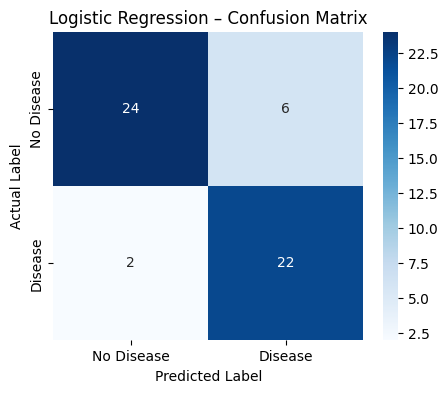

In [ ]:
cm = confusion_matrix(y_test, lr_pred)

plt.figure(figsize=(5,4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Disease", "Disease"],
    yticklabels=["No Disease", "Disease"]
)

plt.title("Logistic Regression – Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.show()

**ROC Curve with AUC Highlighted**

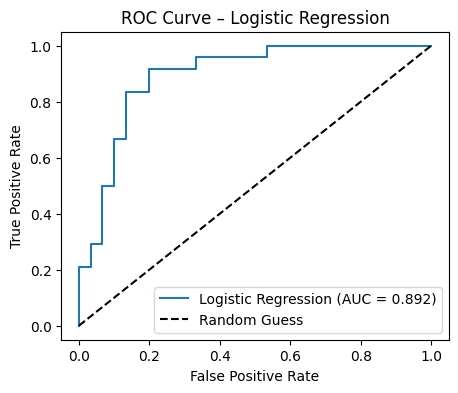

In [ ]:
fpr, tpr, _ = roc_curve(y_test, lr_prob)
roc_auc = roc_auc_score(y_test, lr_prob)

plt.figure(figsize=(5,4))
plt.plot(fpr, tpr, label=f"Logistic Regression (AUC = {roc_auc:.3f})")
plt.plot([0,1], [0,1], 'k--', label="Random Guess")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – Logistic Regression")
plt.legend(loc="lower right")
plt.show()

**MODEL 2: RANDOM FOREST**

In [ ]:
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42
)

rf.fit(X_train_smote, y_train_smote)
rf_pred = rf.predict(X_test_scaled)
rf_prob = rf.predict_proba(X_test_scaled)[:, 1]

In [ ]:
#Evaluation Model
rf_metrics_df = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC"],
    "Value": [
        accuracy_score(y_test, rf_pred)*100,
        precision_score(y_test, rf_pred)*100,
        recall_score(y_test, rf_pred)*100,
        f1_score(y_test, rf_pred)*100,
        roc_auc_score(y_test, rf_prob)*100
    ]
})

rf_metrics_df

,Metric,Value
0,Accuracy,83.333333
1,Precision,80.000000
2,Recall,83.333333
3,F1-Score,81.632653
4,ROC-AUC,87.013889


**Confusion Matrix**

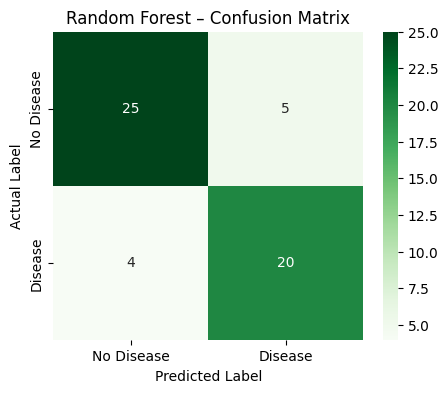

In [ ]:
cm = confusion_matrix(y_test, rf_pred)

plt.figure(figsize=(5,4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=["No Disease", "Disease"],
    yticklabels=["No Disease", "Disease"]
)

plt.title("Random Forest – Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.show()

**ROC Curve**

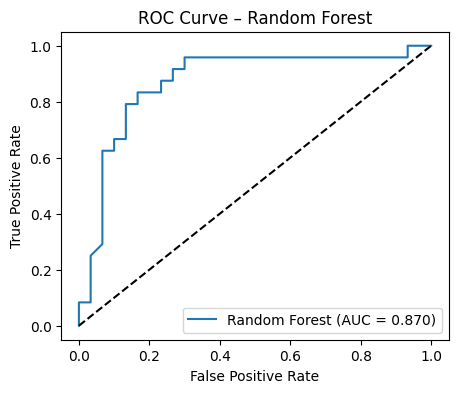

In [ ]:
fpr, tpr, _ = roc_curve(y_test, rf_prob)
roc_auc = roc_auc_score(y_test, rf_prob)

plt.figure(figsize=(5,4))
plt.plot(fpr, tpr, label=f"Random Forest (AUC = {roc_auc:.3f})")
plt.plot([0,1], [0,1], 'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – Random Forest")
plt.legend()
plt.show()

**Feature Importance**

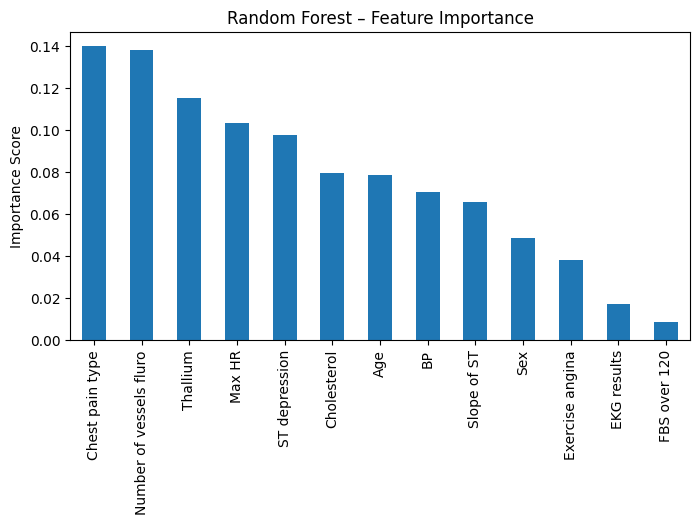

In [ ]:
rf_importance = pd.Series(
    rf.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

plt.figure(figsize=(8,4))
rf_importance.plot(kind="bar")
plt.title("Random Forest – Feature Importance")
plt.ylabel("Importance Score")
plt.show()

**MODEL 3: XGBOOST**

In [ ]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.1,
    subsample=0.8,
    eval_metric="logloss",
    random_state=42
)

xgb.fit(X_train_smote, y_train_smote)
xgb_pred = xgb.predict(X_test_scaled)
xgb_prob = xgb.predict_proba(X_test_scaled)[:, 1]

In [ ]:
xgb_metrics_df = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC"],
    "Value": [
        accuracy_score(y_test, xgb_pred)*100,
        precision_score(y_test, xgb_pred)*100,
        recall_score(y_test, xgb_pred)*100,
        f1_score(y_test, xgb_pred)*100,
        roc_auc_score(y_test, xgb_prob)*100
    ]
})

xgb_metrics_df

,Metric,Value
0,Accuracy,81.481481
1,Precision,76.923077
2,Recall,83.333333
3,F1-Score,80.000000
4,ROC-AUC,85.833333


**Confusion Matrix**

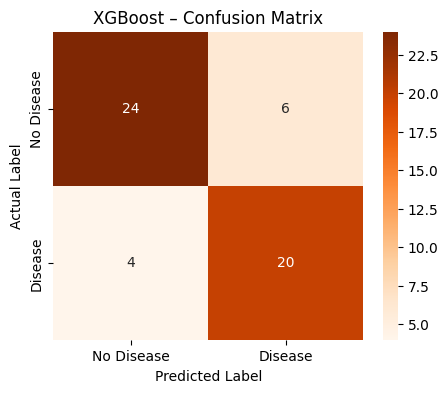

In [ ]:
cm = confusion_matrix(y_test, xgb_pred)

plt.figure(figsize=(5,4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Oranges",
    xticklabels=["No Disease", "Disease"],
    yticklabels=["No Disease", "Disease"]
)

plt.title("XGBoost – Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.show()

**ROC Curve**

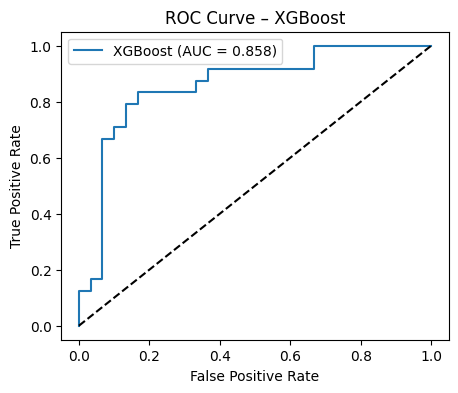

In [ ]:
fpr, tpr, _ = roc_curve(y_test, xgb_prob)
roc_auc = roc_auc_score(y_test, xgb_prob)

plt.figure(figsize=(5,4))
plt.plot(fpr, tpr, label=f"XGBoost (AUC = {roc_auc:.3f})")
plt.plot([0,1], [0,1], 'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – XGBoost")
plt.legend()
plt.show()

**MODEL 4: ANN**

In [ ]:
ann = Sequential([
    Dense(32, activation='relu', input_shape=(X_train_smote.shape[1],)),
    Dropout(0.3),
    Dense(16, activation='relu'),
    Dropout(0.2),
    Dense(1, activation='sigmoid')
])

ann.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

history = ann.fit(
    X_train_smote,
    y_train_smote,
    validation_split=0.2,
    epochs=100,
    batch_size=16,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.3725 - loss: 0.8122 - val_accuracy: 0.3125 - val_loss: 0.7582
Epoch 2/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.4165 - loss: 0.7808 - val_accuracy: 0.4375 - val_loss: 0.7244
Epoch 3/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.4933 - loss: 0.7241 - val_accuracy: 0.4375 - val_loss: 0.7021
Epoch 4/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5980 - loss: 0.6777 - val_accuracy: 0.4792 - val_loss: 0.6828
Epoch 5/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6768 - loss: 0.6270 - val_accuracy: 0.6458 - val_loss: 0.6604
Epoch 6/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7342 - loss: 0.5737 - val_accuracy: 0.6667 - val_loss: 0.6368
Epoch 7/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6923 - loss: 0.5884 - val_accuracy: 0.6875 - val_loss: 0.6093
Epoch 8/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7155 - loss: 0.5531 - val_accuracy: 0.6875 - val_loss: 0.

**Loss vs Epochs**

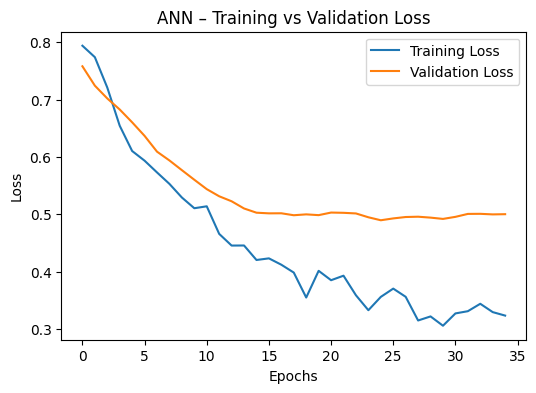

In [ ]:
plt.figure(figsize=(6,4))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("ANN – Training vs Validation Loss")
plt.legend()
plt.show()

**ANN Predictions & Metrics**

In [ ]:
ann_prob = ann.predict(X_test_scaled).ravel()
ann_pred = (ann_prob >= 0.5).astype(int)

ann_metrics_df = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC"],
    "Value": [
        accuracy_score(y_test, ann_pred)*100,
        precision_score(y_test, ann_pred)*100,
        recall_score(y_test, ann_pred)*100,
        f1_score(y_test, ann_pred)*100,
        roc_auc_score(y_test, ann_prob)*100
    ]
})

ann_metrics_df

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step


,Metric,Value
0,Accuracy,85.185185
1,Precision,80.769231
2,Recall,87.500000
3,F1-Score,84.000000
4,ROC-AUC,89.444444


**ROC Curve**

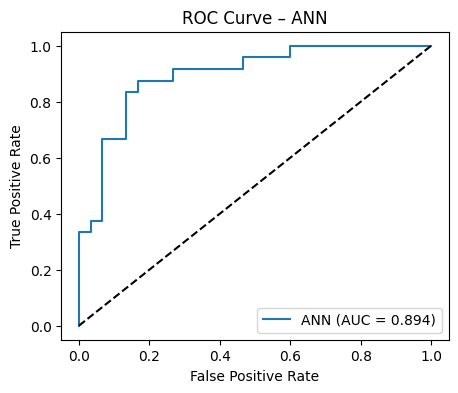

In [ ]:
fpr, tpr, _ = roc_curve(y_test, ann_prob)
roc_auc = roc_auc_score(y_test, ann_prob)

plt.figure(figsize=(5,4))
plt.plot(fpr, tpr, label=f"ANN (AUC = {roc_auc:.3f})")
plt.plot([0,1], [0,1], 'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – ANN")
plt.legend()
plt.show()

**SHAP**

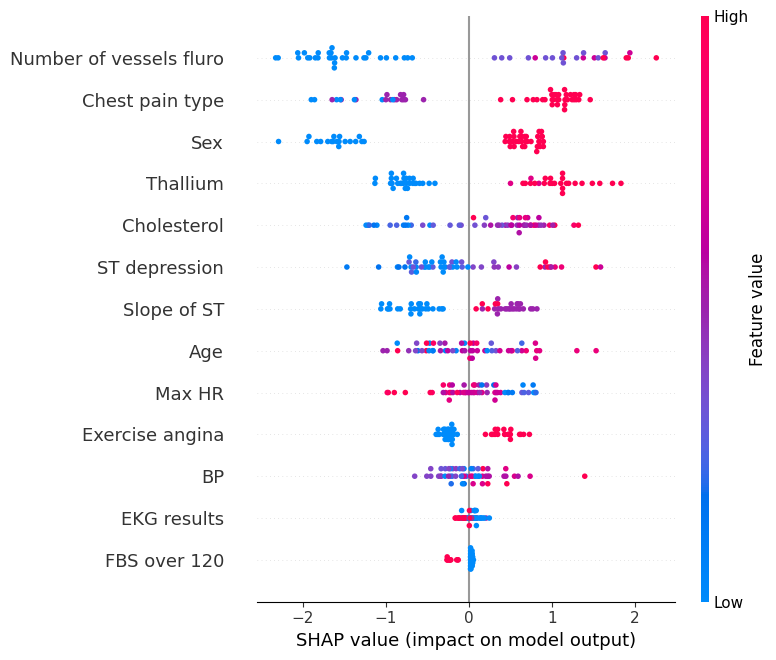

In [ ]:
explainer = shap.Explainer(xgb, X_train_smote)
shap_values = explainer(X_test_scaled)

shap.summary_plot(
    shap_values,
    X_test,
    feature_names=X.columns
)

**LIME**

In [ ]:
lime_explainer = LimeTabularExplainer(
    X_train_scaled,
    feature_names=X.columns,
    class_names=["No Disease", "Disease"],
    mode="classification",
    discretize_continuous=True
)

sample_index = 3

lime_exp = lime_explainer.explain_instance(
    X_test_scaled[sample_index],
    xgb.predict_proba
)

lime_exp.show_in_notebook()

**COMPARISON**

In [ ]:
final_results = pd.DataFrame({
    "Logistic Regression": lr_metrics_df.set_index("Metric")["Value"],
    "Random Forest": rf_metrics_df.set_index("Metric")["Value"],
    "XGBoost": xgb_metrics_df.set_index("Metric")["Value"],
    "ANN": ann_metrics_df.set_index("Metric")["Value"]
})

final_results

,Logistic Regression,Random Forest,XGBoost,ANN
Metric,,,,
Accuracy,85.185185,83.333333,81.481481,85.185185
Precision,78.571429,80.000000,76.923077,80.769231
Recall,91.666667,83.333333,83.333333,87.500000
F1-Score,84.615385,81.632653,80.000000,84.000000
ROC-AUC,89.166667,87.013889,85.833333,89.444444
